##Data Loading



In [ ]:
import pandas as pd

try:
    df_train = pd.read_csv('train_data.csv')
    df_test = pd.read_csv('test_data.csv')
    display(df_train.head())
    display(df_test.head())


,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2016-12-26T00:00:00.000Z,Purchased on Black FridayPros - Great Price (e...,Powerful tablet,Positive
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",2018-01-17T00:00:00.000Z,I purchased two Amazon in Echo Plus and two do...,Amazon Echo Plus AWESOME,Positive
2,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few ...,Average,Neutral
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Amazon,"eBook Readers,Fire Tablets,Electronics Feature...","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,"very good product. Exactly what I wanted, and ...",Greattttttt,Positive
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bough...,Very durable!,Positive


,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title
0,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",Amazon,"Fire Tablets,Computers/Tablets & Networking,Ta...",Electronics,2016-05-23T00:00:00.000Z,Amazon kindle fire has a lot of free app and c...,very handy device
1,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Computers,Amazon Echo,Virtual Assistant Speake...","Electronics,Hardware",2018-01-02T00:00:00.000Z,The Echo Show is a great addition to the Amazo...,Another winner from Amazon
2,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2017-01-02T00:00:00.000Z,Great value from Best Buy. Bought at Christmas...,simple to use and reliable so far
3,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-03-25T00:00:00.000Z,"I use mine for email, Facebook ,games and to g...",Love it!!!
4,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Computers,Amazon Echo,Virtual Assistant Speake...","Electronics,Hardware",2017-11-15T00:00:00.000Z,This is a fantastic item & the person I bought...,Fantastic!


## Data exploration

Explore the training and testing datasets.


Training Data Shape: (4000, 8)
Testing Data Shape: (1000, 7)

Training Data Types:
 Name of the product    object
Product Brand          object
categories             object
primaryCategories      object
reviews.date           object
reviews.text           object
reviews.title          object
sentiment              object
dtype: object

Testing Data Types:
 Name of the product    object
Product Brand          object
categories             object
primaryCategories      object
reviews.date           object
reviews.text           object
reviews.title          object
dtype: object

Training Data Descriptive Statistics:
                                       Name of the product Product Brand  \
count                                                4000          4000   
unique                                                 23             1   
top     Amazon Echo Show Alexa-enabled Bluetooth Speak...        Amazon   
freq                                                  676          4000   



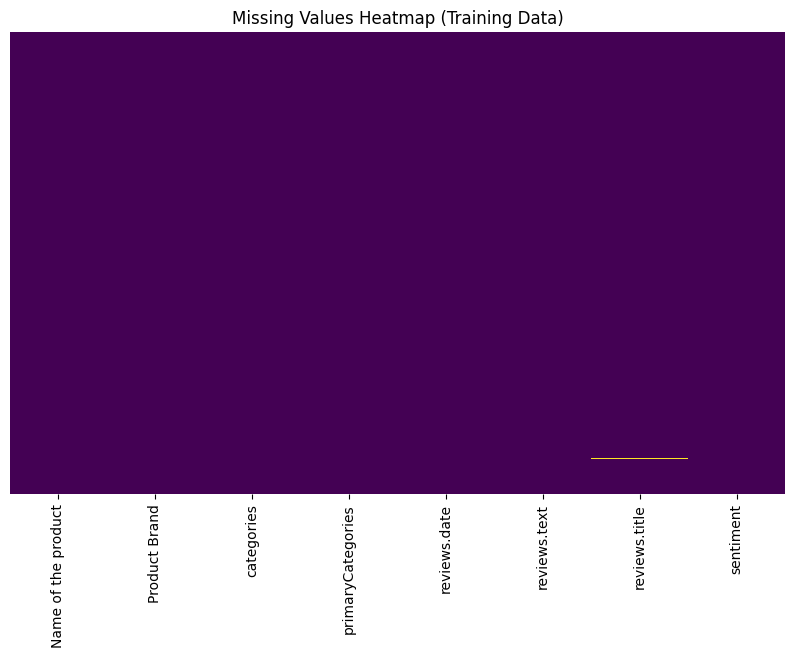

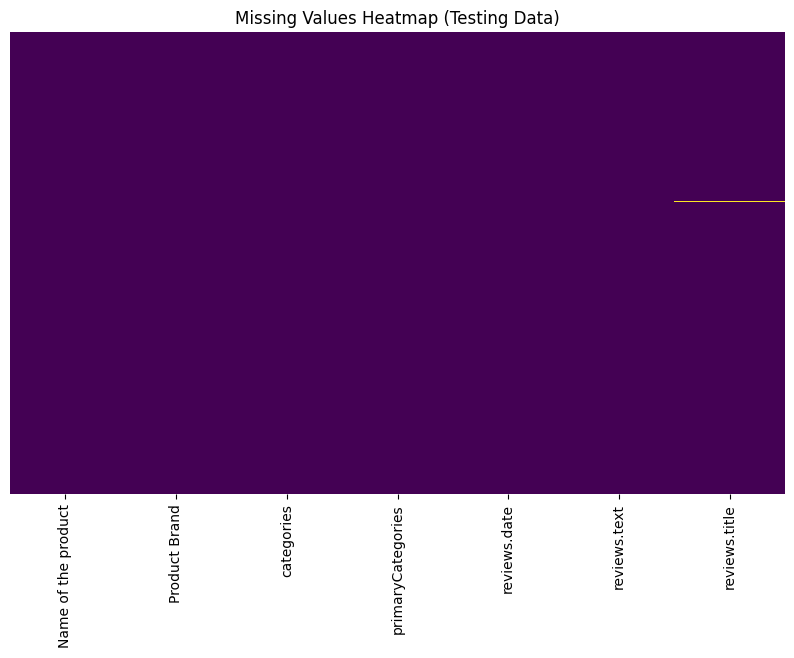

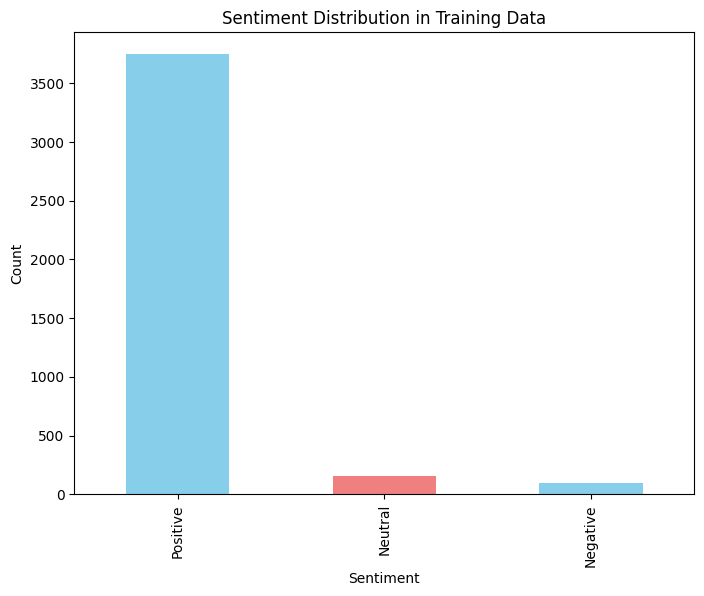


Training Data Word Count Statistics:
 count    4000.000000
mean       30.567500
std        40.813385
min         1.000000
25%        14.000000
50%        21.000000
75%        35.000000
max      1539.000000
Name: word_count, dtype: float64

Testing Data Word Count Statistics:
 count    1000.000000
mean       32.499000
std        60.726516
min         4.000000
25%        14.000000
50%        21.000000
75%        35.000000
max      1539.000000
Name: word_count, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Shape and Structure
print("Training Data Shape:", df_train.shape)
print("Testing Data Shape:", df_test.shape)
print("\nTraining Data Types:\n", df_train.dtypes)
print("\nTesting Data Types:\n", df_test.dtypes)

# 2. Descriptive Statistics
print("\nTraining Data Descriptive Statistics:\n", df_train.describe(include='all'))
print("\nTesting Data Descriptive Statistics:\n", df_test.describe(include='all'))
print("\nTraining Data Sentiment Distribution:\n", df_train['sentiment'].value_counts(normalize=True))

# 3. Missing Values
print("\nTraining Data Missing Values:\n", df_train.isnull().sum())
print("\nTesting Data Missing Values:\n", df_test.isnull().sum())
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap (Training Data)")
plt.show()
plt.figure(figsize=(10, 6))
sns.heatmap(df_test.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap (Testing Data)")
plt.show()


# 4. Data Distribution (Numerical Features - No clear numerical features besides date)

# 4. Data Distribution (Categorical Features and Target Variable)
plt.figure(figsize=(8, 6))
df_train['sentiment'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Sentiment Distribution in Training Data')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


# 6. Text Data Exploration
# Example text statistics (can be extended)
df_train['word_count'] = df_train['reviews.text'].str.split().str.len()
df_test['word_count'] = df_test['reviews.text'].str.split().str.len()
print("\nTraining Data Word Count Statistics:\n", df_train['word_count'].describe())
print("\nTesting Data Word Count Statistics:\n", df_test['word_count'].describe())


# 7. Documentation (Observations will be printed inline above)

# 8. Comparison (Observations will be printed inline above, comparing distributions and missing values across datasets)

## Data cleaning

Clean the training and testing datasets by handling missing values and addressing inconsistencies.


In [ ]:
# Impute missing values in 'reviews.title'
df_train['reviews.title'] = df_train['reviews.title'].fillna("No Title")
df_test['reviews.title'] = df_test['reviews.title'].fillna("No Title")

# Check for inconsistencies in categorical columns (example: 'sentiment')
# Note: The test set does not have the 'sentiment' column, so we skip the comparison.

# Outlier Detection and Handling (Optional):
# Check for outliers in 'word_count' (example using IQR method)
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

df_train = handle_outliers_iqr(df_train, 'word_count')
df_test = handle_outliers_iqr(df_test, 'word_count')

# Data Type Consistency Check
print("Training Data Types:\n", df_train.dtypes)
print("\nTesting Data Types:\n", df_test.dtypes)

Training Data Types:
 Name of the product     object
Product Brand           object
categories              object
primaryCategories       object
reviews.date            object
reviews.text            object
reviews.title           object
sentiment               object
word_count             float64
dtype: object

Testing Data Types:
 Name of the product     object
Product Brand           object
categories              object
primaryCategories       object
reviews.date            object
reviews.text            object
reviews.title           object
word_count             float64
dtype: object


## Data preparation

Combine the cleaned training and testing datasets for consistent preprocessing.


In [ ]:
# Add a 'dataset' column to each DataFrame
df_train['dataset'] = 'train'
df_test['dataset'] = 'test'

# Concatenate the DataFrames
df_combined = pd.concat([df_train, df_test], ignore_index=True)

# Verify the shape of the combined DataFrame
print("Shape of combined DataFrame:", df_combined.shape)

# Reset index (optional)
df_combined = df_combined.reset_index(drop=True)
display(df_combined.head())

Shape of combined DataFrame: (5000, 10)


,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment,word_count,dataset
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2016-12-26T00:00:00.000Z,Purchased on Black FridayPros - Great Price (e...,Powerful tablet,Positive,66.5,train
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",2018-01-17T00:00:00.000Z,I purchased two Amazon in Echo Plus and two do...,Amazon Echo Plus AWESOME,Positive,66.5,train
2,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few ...,Average,Neutral,15.0,train
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Amazon,"eBook Readers,Fire Tablets,Electronics Feature...","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,"very good product. Exactly what I wanted, and ...",Greattttttt,Positive,12.0,train
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bough...,Very durable!,Positive,35.0,train


## Feature engineering

Engineer features from the text data in `df_combined`.  Specifically, create TF-IDF features from the 'reviews.text' column.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Instantiate TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')

# Fit and transform the text data
tfidf_features = vectorizer.fit_transform(df_combined['reviews.text'])

# Convert to dense array
tfidf_array = tfidf_features.toarray()

# Create new DataFrame from the dense array
tfidf_df = pd.DataFrame(tfidf_array, columns=[f'tfidf_{word}' for word in vectorizer.get_feature_names_out()])

# Concatenate with original DataFrame
df_combined = pd.concat([df_combined, tfidf_df], axis=1)

# Remove original text column
df_combined = df_combined.drop('reviews.text', axis=1)

display(df_combined.head())

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.title,sentiment,word_count,dataset,tfidf_00,...,tfidf_äôs,tfidf_äôs fun,tfidf_äôs great,tfidf_äôt,tfidf_äôt know,tfidf_äôt use,tfidf_äôt wait,tfidf_äôve,tfidf_äù,tfidf_äúalexa
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2016-12-26T00:00:00.000Z,Powerful tablet,Positive,66.5,train,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",2018-01-17T00:00:00.000Z,Amazon Echo Plus AWESOME,Positive,66.5,train,0.0,...,0.113524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",2017-12-20T00:00:00.000Z,Average,Neutral,15.0,train,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Amazon,"eBook Readers,Fire Tablets,Electronics Feature...","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,Greattttttt,Positive,12.0,train,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-01-23T00:00:00.000Z,Very durable!,Positive,35.0,train,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data splitting

Split the combined dataset (`df_combined`) back into training and testing sets.  Stratify the split based on the 'sentiment' column to maintain class proportions.


In [ ]:
# Fill NaN values in the 'sentiment' column with the most frequent value from the training data
most_frequent_sentiment = df_train['sentiment'].mode()[0]
df_combined['sentiment'] = df_combined['sentiment'].fillna(most_frequent_sentiment)

from sklearn.model_selection import train_test_split

# Split the combined dataset back into training and testing sets
df_train_final, df_test_final = train_test_split(
    df_combined, test_size=1000, random_state=42, stratify=df_combined['sentiment']
)

# Verify the shapes of the resulting DataFrames
print("Shape of df_train_final:", df_train_final.shape)
print("Shape of df_test_final:", df_test_final.shape)

# Ensure the 'sentiment' column is present in df_train_final
if 'sentiment' in df_train_final.columns:
    print("'sentiment' column is present in df_train_final.")
else:
    print("'sentiment' column is NOT present in df_train_final.")

Shape of df_train_final: (4000, 5009)
Shape of df_test_final: (1000, 5009)
'sentiment' column is present in df_train_final.


## Data analysis


Analyze the engineered features (TF-IDF features) in `df_train_final` and explore their relationships with the target variable ('sentiment').


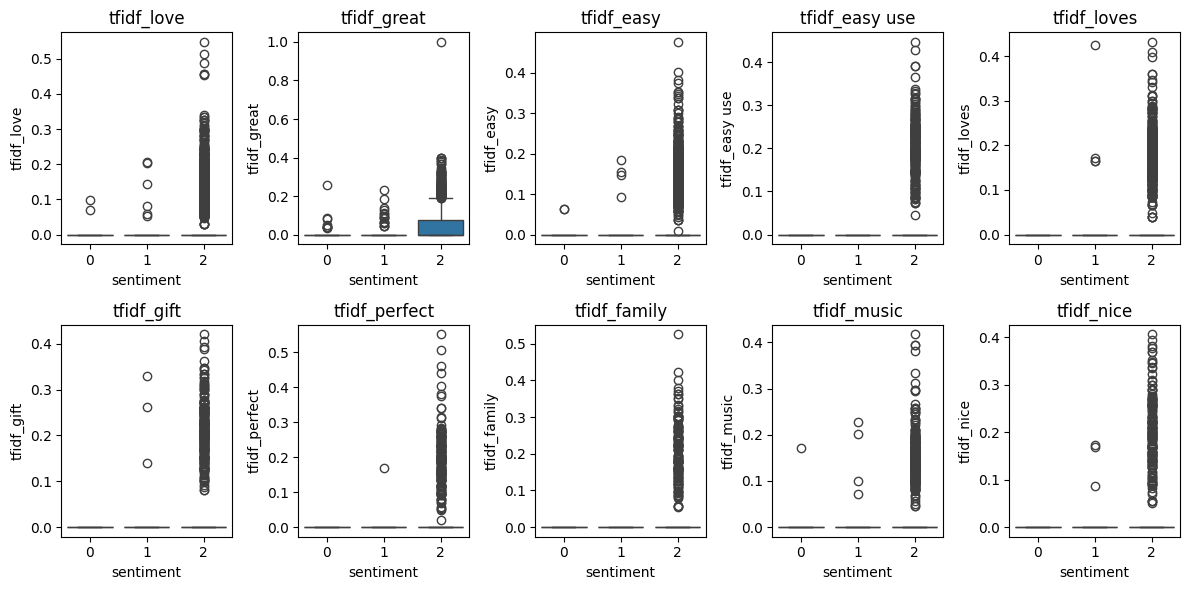

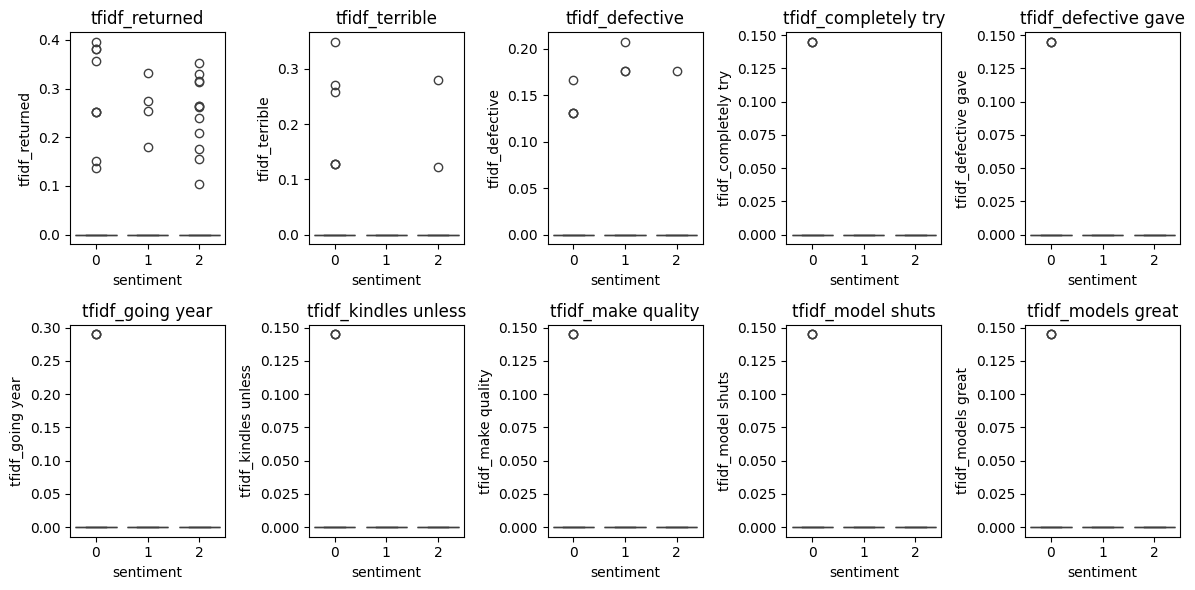

Top 10 Positive TF-IDF Features:
 tfidf_love        0.083299
tfidf_great       0.081311
tfidf_easy        0.073829
tfidf_easy use    0.056356
tfidf_loves       0.053294
tfidf_gift        0.041664
tfidf_perfect     0.040463
tfidf_family      0.037738
tfidf_music       0.037233
tfidf_nice        0.034793
Name: sentiment, dtype: float64

Top 10 Negative TF-IDF Features:
 tfidf_returned         -0.206736
tfidf_terrible         -0.188971
tfidf_defective        -0.170495
tfidf_completely try   -0.166464
tfidf_defective gave   -0.166464
tfidf_going year       -0.166464
tfidf_kindles unless   -0.166464
tfidf_make quality     -0.166464
tfidf_model shuts      -0.166464
tfidf_models great     -0.166464
Name: sentiment, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert 'sentiment' to numerical values
le = LabelEncoder()
df_train_final['sentiment'] = le.fit_transform(df_train_final['sentiment'])

# Calculate correlations
tfidf_cols = [col for col in df_train_final.columns if col.startswith('tfidf_')]
correlations = df_train_final[tfidf_cols + ['sentiment']].corr()['sentiment'].drop('sentiment')

# Identify top features
top_positive_features = correlations.nlargest(10)
top_negative_features = correlations.nsmallest(10)

# Visualization (using box plots)
plt.figure(figsize=(12, 6))
for i, feature in enumerate(top_positive_features.index):
    plt.subplot(2, 5, i + 1)
    sns.boxplot(x=df_train_final['sentiment'], y=df_train_final[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i, feature in enumerate(top_negative_features.index):
    plt.subplot(2, 5, i + 1)
    sns.boxplot(x=df_train_final['sentiment'], y=df_train_final[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

# Print observations
print("Top 10 Positive TF-IDF Features:\n", top_positive_features)
print("\nTop 10 Negative TF-IDF Features:\n", top_negative_features)

## Model training

Train a Multinomial Naive Bayes classifier on the training data.


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Identify TF-IDF feature columns
tfidf_cols = [col for col in df_train_final.columns if col.startswith('tfidf_')]

# Define features (X) and target variable (y)
X = df_train_final[tfidf_cols]
y = df_train_final['sentiment']

# Initialize and train the Multinomial Naive Bayes classifier
mnb_model = MultinomialNB(alpha=1.0).fit(X, y)

## Model evaluation

Evaluate the performance of the trained Multinomial Naive Bayes model (`mnb_model`) on the test data (`df_test_final`)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.949
Precision: 0.9024524524524524
Recall: 0.949
F1-score: 0.9251410979989738


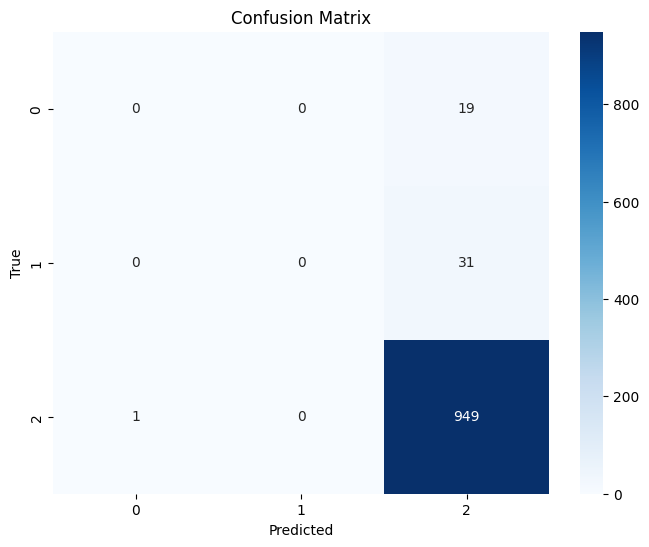

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Prepare the test data
tfidf_cols = [col for col in df_train_final.columns if col.startswith('tfidf_')]
X_test = df_test_final[tfidf_cols]
y_test = df_test_final['sentiment']

# Ensure y_test is in the same format as the training data's target (numerical labels)
if isinstance(y_test.iloc[0], str):
    le_test = LabelEncoder()  # Use a separate LabelEncoder for the test set
    y_test = le_test.fit_transform(y_test)
elif not all(isinstance(val, (int, np.integer)) for val in y_test):
    y_test = y_test.astype(int) # Convert to int if not already numerical

# Make predictions
y_pred = mnb_model.predict(X_test)


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Model training

Train a Multi-class Support Vector Machine (SVM) classifier on the training data (`df_train_final`)


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder

# Prepare the training data
tfidf_cols = [col for col in df_train_final.columns if col.startswith('tfidf_')]
X_train = df_train_final[tfidf_cols]
y_train = df_train_final['sentiment']

# Initialize the SVM classifier with class_weight='balanced'
svm_model = LinearSVC(class_weight='balanced', random_state=42)

# Train the SVM classifier
svm_model.fit(X_train, y_train)

LinearSVC(class_weight='balanced', random_state=42)

## Model evaluation

Evaluate the performance of the trained Support Vector Machine (SVM) model (`svm_model`) on the test data (`df_test_final`)


Accuracy: 0.947
Precision: 0.9326450376454484
Recall: 0.947
F1-score: 0.9380773405079288


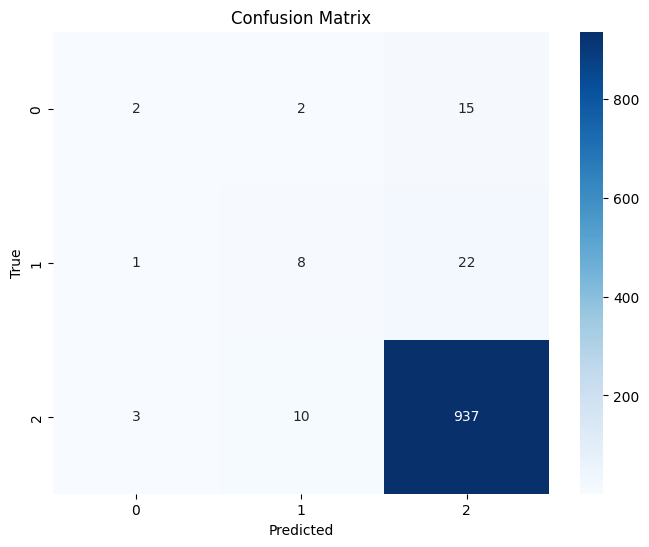

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the test data
tfidf_cols = [col for col in df_train_final.columns if col.startswith('tfidf_')]
X_test = df_test_final[tfidf_cols]
y_test = df_test_final['sentiment']

# Ensure y_test is numerically encoded using the same LabelEncoder as the training data
y_test = le.transform(y_test)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Model training

Train a feedforward neural network classifier on the training data (`df_train_final`)


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Prepare the training data
tfidf_cols = [col for col in df_train_final.columns if col.startswith('tfidf_')]
X_train = df_train_final[tfidf_cols]
y_train = df_train_final['sentiment']

# Ensure y_train is numerically encoded
if not all(isinstance(val, (int, np.integer)) for val in y_train):
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)

# Define the model architecture
nn_model = Sequential()
nn_model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(3, activation='softmax'))  # 3 output neurons for 3 sentiment classes


# Compile the model
nn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
nn_model.fit(X_train, y_train, epochs=10, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9373 - loss: 0.5662
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9473 - loss: 0.1613
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9543 - loss: 0.0881
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9726 - loss: 0.0610
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9960 - loss: 0.0227
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9971 - loss: 0.0117
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9956 - loss: 0.0119
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9937 - loss: 0.0117
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9962 - loss: 0.0080
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9966 - loss: 0.0071
